In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
train_df = pd.read_csv('train.tsv', sep = '\t')
test_df = pd.read_csv('test.tsv', sep = '\t')

In [29]:
# 查看数据结构
print('训练集规模（行，列）:', train_df.shape)
print('测试集规模（行，列）:', test_df.shape)

print('\n训练集前5行:')
display(train_df.head())

print('\n测试集前5行:')
display(test_df.head())

训练集规模（行，列）: (156060, 4)
测试集规模（行，列）: (66292, 3)

训练集前5行:


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2



测试集前5行:


,PhraseId,SentenceId,Phrase
0,156061,8545,An intermittently pleasing but mostly routine ...
1,156062,8545,An intermittently pleasing but mostly routine ...
2,156063,8545,An
3,156064,8545,intermittently pleasing but mostly routine effort
4,156065,8545,intermittently pleasing but mostly routine


In [16]:
print('\n查看数据基本信息:')
display(train_df.info())

print('\n情感标签的分布:')
sentiment_counts = train_df['Sentiment'].value_counts().sort_index()
print(sentiment_counts)


查看数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   PhraseId    156060 non-null  int64 
 1   SentenceId  156060 non-null  int64 
 2   Phrase      156060 non-null  object
 3   Sentiment   156060 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.8+ MB


None


情感标签的分布:
Sentiment
0     7072
1    27273
2    79582
3    32927
4     9206
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Sentiment Labels')

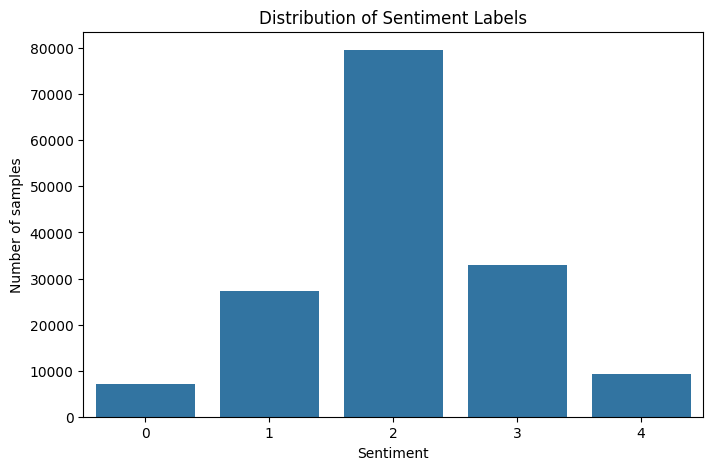

In [17]:
# 绘图
plt.figure(figsize = (8,5))
sns.barplot(x = sentiment_counts.index,
           y = sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Number of samples")
plt.title("Distribution of Sentiment Labels")

In [18]:
import re
import nltk
from nltk.corpus import stopwords

In [21]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1.转小写
    text.lower()
    # 2.移除标点符号和数字
    text = re.sub(r'[^a-zA-Z\s]',' ',text)
    # 3.将多个连续空格替换成单个空格
    text = re.sub(r'\s+',' ',text).strip()
    return text
# 定义一个分词和去除停用词的函数
def tokrnize_and_remove_stopwords(text):
    tokens = text.split()
    # 移除停用词
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return tokens

In [32]:
# 应用清洗函数到 'Phrase' 列
print("正在清洗文本...")
train_df['Phrase'] = train_df['Phrase'].astype(str).apply(clean_text)

# 应用分词和去停用词
print("正在分词和去除停用词...")
train_df['Phrase'] = train_df['Phrase'].apply(tokrnize_and_remove_stopwords)


正在清洗文本...
正在分词和去除停用词...


In [33]:
print("清洗后phrase：")
display(train_df['Phrase'].head(10))

清洗后phrase：


0    [series, escapades, demonstrating, adage, good...
1    [series, escapades, demonstrating, adage, good...
2                                             [series]
3                                                   []
4                                             [series]
5       [escapades, demonstrating, adage, good, goose]
6                                                   []
7       [escapades, demonstrating, adage, good, goose]
8                                          [escapades]
9                  [demonstrating, adage, good, goose]
Name: Phrase, dtype: object

In [37]:
# 去除空值
# 计算每行的词数量
train_df['word_count'] = train_df['Phrase'].apply(len)

# 查看空值情况
print("空值统计:")
print(train_df[train_df['word_count'] == 0])

空值统计:
        PhraseId  SentenceId Phrase  Sentiment  word_count
3              4           1     []          2           0
6              7           1     []          2           0
13            14           1     []          2           0
16            17           1     []          2           0
18            19           1     []          2           0
...          ...         ...    ...        ...         ...
154241    154242        8427     []          2           0
154523    154524        8446     []          2           0
154524    154525        8446     []          2           0
154864    154865        8470     []          2           0
155763    155764        8525     []          2           0

[1475 rows x 5 columns]


In [44]:
# 删除空值，并去掉辅助列
train_df_cleaned = train_df[train_df['word_count'] > 0].reset_index(drop=True)
train_df_cleaned.drop(labels = 'word_count', axis = 1, inplace = True)
train_df_cleaned.head(10)

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,"[series, escapades, demonstrating, adage, good...",1
1,2,1,"[series, escapades, demonstrating, adage, good...",2
2,3,1,[series],2
3,5,1,[series],2
4,6,1,"[escapades, demonstrating, adage, good, goose]",2
5,8,1,"[escapades, demonstrating, adage, good, goose]",2
6,9,1,[escapades],2
7,10,1,"[demonstrating, adage, good, goose]",2
8,11,1,"[demonstrating, adage]",2
9,12,1,[demonstrating],2


In [50]:
# 去重
# 将列表转换为元组（元组是可哈希的）
train_df_cleaned['Phrase_tuple'] = train_df_cleaned['Phrase'].apply(tuple)

# 检查重复
duplicates = train_df_cleaned.duplicated(subset=['Phrase_tuple', 'Sentiment'], keep=False)
print("重复样本数量:", duplicates.sum())
print("重复比例: {:.2f}%".format(duplicates.sum()/len(train_df_cleaned)*100))

# 去重
train_df_cleaned = train_df_cleaned.drop_duplicates(subset=['Phrase_tuple', 'Sentiment']).reset_index(drop=True)

# 删除临时列
train_df_cleaned = train_df_cleaned.drop('Phrase_tuple', axis=1)

print("去重后的形状:", train_df_cleaned.shape)

重复样本数量: 78913
重复比例: 51.05%
去重后的形状: (107687, 4)


In [51]:
# train_df_cleaned.to_csv('train_df_cleaned.csv', index=False, encoding='utf-8-sig')

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
# 文本向量化
# TF-IDF 和 Word2Vec/GloVe
train_df_cleaned['processed_text'] = train_df_cleaned['Phrase'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# 拟合并转换训练数据
print("正在生成 TF-IDF 特征...")
X_tfidf = tfidf_vectorizer.fit_transform(train_df_cleaned['processed_text'])

# 获取标签
y = train_df_cleaned['Sentiment']

print(f"TF-IDF特征矩阵的形状: {X_tfidf.shape}")
print(f"标签的形状: {y.shape}")

正在生成 TF-IDF 特征...
TF-IDF特征矩阵的形状: (107687, 5000)
标签的形状: (107687,)


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# --- 训练朴素贝叶斯 ---
print("\n--- 训练朴素贝叶斯 ---")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print(f"朴素贝叶斯准确率: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb, digits=4))

# --- 训练线性SVM ---
print("\n--- 训练线性SVM ---")
# 使用LinearSVC，适合大规模数据，注意max_iter可能需要调大
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print(f"SVM准确率: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, digits=4))

训练集大小: (86149, 5000)
测试集大小: (21538, 5000)

--- 训练朴素贝叶斯 ---
朴素贝叶斯准确率: 0.5274
              precision    recall  f1-score   support

           0     0.4419    0.0173    0.0332      1101
           1     0.4545    0.1632    0.2402      4043
           2     0.5421    0.9075    0.6787     10151
           3     0.4770    0.2966    0.3658      4787
           4     0.6806    0.0337    0.0641      1456

    accuracy                         0.5274     21538
   macro avg     0.5192    0.2837    0.2764     21538
weighted avg     0.5154    0.5274    0.4523     21538


--- 训练线性SVM ---
SVM准确率: 0.5489
              precision    recall  f1-score   support

           0     0.4193    0.1580    0.2296      1101
           1     0.4372    0.3013    0.3567      4043
           2     0.6059    0.8098    0.6932     10151
           3     0.4604    0.3973    0.4266      4787
           4     0.4828    0.2122    0.2948      1456

    accuracy                         0.5489     21538
   macro avg     0.4811

In [56]:
# 在test数据集上查看效果
# 应用清洗函数到 'Phrase' 列
print("正在清洗文本...")
test_df['Phrase'] = test_df['Phrase'].astype(str).apply(clean_text)

# 应用分词和去停用词
print("正在分词和去除停用词...")
test_df['Phrase'] = test_df['Phrase'].apply(tokrnize_and_remove_stopwords)

正在清洗文本...
正在分词和去除停用词...


In [59]:
test_df['word_count'] = test_df['Phrase'].apply(len)
test_df_cleaned = test_df[test_df['word_count'] > 0].reset_index(drop=True)

test_df_cleaned.drop(labels = 'word_count', axis = 1, inplace = True)
test_df_cleaned.head(10)

,PhraseId,SentenceId,Phrase
0,156061,8545,"[An, intermittently, pleasing, mostly, routine..."
1,156062,8545,"[An, intermittently, pleasing, mostly, routine..."
2,156063,8545,[An]
3,156064,8545,"[intermittently, pleasing, mostly, routine, ef..."
4,156065,8545,"[intermittently, pleasing, mostly, routine]"
5,156066,8545,"[intermittently, pleasing]"
6,156067,8545,"[intermittently, pleasing]"
7,156068,8545,[intermittently]
8,156069,8545,[pleasing]
9,156071,8545,"[mostly, routine]"


In [61]:
# 去重
# 将列表转换为元组（元组是可哈希的）
test_df_cleaned['Phrase_tuple'] = test_df_cleaned['Phrase'].apply(tuple)

# 检查重复
duplicates = test_df_cleaned.duplicated(subset=['Phrase_tuple'], keep=False)
print("重复样本数量:", duplicates.sum())
print("重复比例: {:.2f}%".format(duplicates.sum()/len(test_df_cleaned)*100))

# 去重
test_df_cleaned = test_df_cleaned.drop_duplicates(subset=['Phrase_tuple']).reset_index(drop=True)

# 删除临时列
test_df_cleaned = test_df_cleaned.drop('Phrase_tuple', axis=1)

print("去重后的形状:", test_df_cleaned.shape)

重复样本数量: 44839
重复比例: 68.43%
去重后的形状: (38365, 3)


In [63]:
test_df_cleaned['processed_text'] = test_df_cleaned['Phrase'].apply(lambda x: ' '.join(x))

# 2. 使用已训练的tfidf_vectorizer转换测试数据
X_test_tfidf = tfidf_vectorizer.transform(test_df_cleaned['processed_text'])
print(f"测试数据TF-IDF矩阵形状: {X_test_tfidf.shape}")

# 3. 使用训练好的模型进行预测
y_pred_nb_test = nb_model.predict(X_test_tfidf)
y_pred_svm_test = svm_model.predict(X_test_tfidf)

# 4. 输出预测结果
print("朴素贝叶斯预测结果:", y_pred_nb_test)
print("SVM预测结果:", y_pred_svm_test)

# 5. 如果需要保存预测结果
output_df = pd.DataFrame({
    'PhraseId': test_df_cleaned['PhraseId'],
    'Sentiment': y_pred_svm_test  # 假设你选择SVM的预测结果
})
output_df.to_csv('submission.csv', index=False)
print("预测结果已保存到 submission.csv")

测试数据TF-IDF矩阵形状: (38365, 5000)
朴素贝叶斯预测结果: [3 3 2 ... 2 2 2]
SVM预测结果: [3 2 3 ... 2 1 2]
预测结果已保存到 submission.csv
